### Cell 1: Import Libraries
- `os`, `random`, `json`, `time`: Standard Python modules for file operations, randomness, JSON handling, and timing.
- `torch`, `torchvision`, `torch.nn`: PyTorch and its vision utilities for deep learning.
- `cv2`: OpenCV for image processing.
- `numpy`: Numerical operations.
- `matplotlib.pyplot`, `seaborn`: Visualization libraries.
- `datasets`, `DataLoader`: PyTorch utilities for loading image datasets.
- `efficientnet_v2_s`, `EfficientNet_V2_S_Weights`: Pretrained EfficientNet model and weights.

In [6]:
import os , random , json , time
import torch
import torchvision
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

### Cell 2: Set Dataset Paths
- `train_dir` and `test_dir` specify the folders containing training and testing images.

In [7]:
train_dir = "Training"
test_dir = "Testing"

### Cell 3: Define Image Transformations
- Uses torchvision's `transforms` to preprocess images for training and testing.
- Converts grayscale images to 3 channels, resizes, normalizes, and converts to tensor.

In [8]:
from torchvision import transforms

IMG_SIZE = 224
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # convert 1→3 channels
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # resize images
    transforms.ToTensor(),                         # convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

### Cell 4: Load Datasets and Create DataLoaders
- Loads images using `ImageFolder` and applies transforms.
- Splits training data into train/validation sets.
- Creates PyTorch DataLoaders for batching and shuffling.

In [25]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data  = datasets.ImageFolder(root=test_dir, transform=test_transforms)
print("Train data", train_data)
print("Test data length",len(test_data))
from torch.utils.data import random_split, DataLoader

num_train = len(train_data)

# 10% for validation
val_size = int(0.1 * num_train)
train_size = num_train - val_size

# Split the dataset
train_subset, val_subset = random_split(train_data, [train_size, val_size])

class_names = train_data.classes
print("Classes:", class_names)

BATCH_SIZE = 16

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_data.classes          
class_to_idx = train_data.class_to_idx   

print("Class Names:", class_names)
print("Class to Index Mapping:", class_to_idx)

print(len(train_subset))
print(len(val_subset))
print("Train Loader", train_loader)

Train data Dataset ImageFolder
    Number of datapoints: 5712
    Root location: Training
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=3)
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data length 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class Names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to Index Mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
5141
571
Train Loader <torch.utils.data.dataloader.DataLoader object at 0x000001FA75E6B950>


### Cell 5: Visualize Sample Images
- Randomly selects 10 images from the training set.
- De-normalizes and plots them with their class labels.

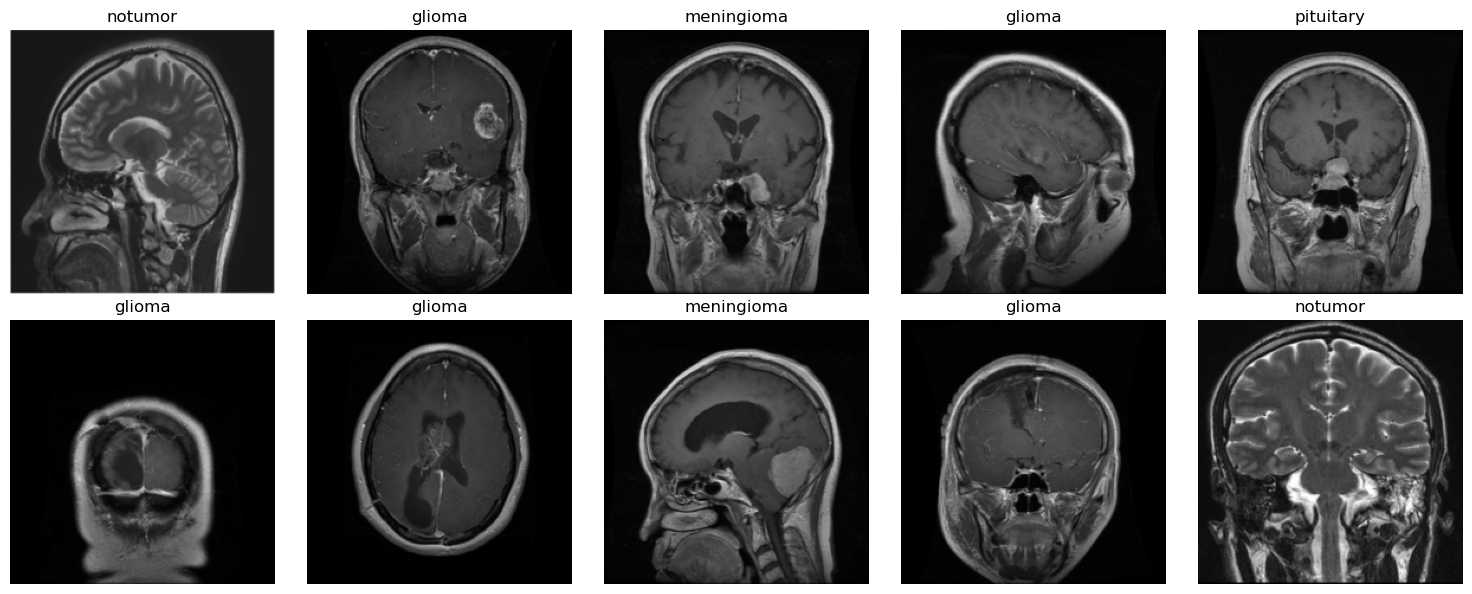

In [10]:
indices = random.sample(range(len(train_data)), 10)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    img, label = train_data[idx]   # get (image_tensor, label)
    
    # Convert tensor to numpy for plotting
    img = img.permute(1, 2, 0).numpy()   # CHW → HWC
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # de-normalize
    img = img.clip(0, 1)
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Cell 6: Setup Device and Model
- Checks if a GPU is available and sets the device accordingly.
- Loads the EfficientNetV2-S model with pretrained weights.
- Modifies the final layer to match the number of classes in our dataset.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load pretrained EfficientNetV2-S
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

# Change the final layer for 4 classes
from torch import nn
num_classes = 4
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

### Cell 7: Print Device
- Confirms the device (CPU or GPU) being used for training.

In [12]:
print(device)

cuda


### Cell 8: Set Loss Function and Optimizer
- `lr`: Learning rate for the optimizer.
- `criterion`: Loss function, here CrossEntropyLoss is used for multi-class classification.
- `optimizer`: AdamW optimizer is used for training the model.

In [13]:
import torch.optim as optim

lr = 0.003
criterion = nn.CrossEntropyLoss()   # Standard for multi-class classification
optimizer = optim.AdamW(model.parameters(), lr=lr)  # AdamW optimizer


### Cell 9: Inspect DataLoader
- Prints the train_loader object to inspect its properties.

In [14]:
print(train_loader)

### Cell 10: Inspect a Batch of Data
- Retrieves and prints the shape of a batch of images and labels from the train_loader.

In [15]:
images, labels = next(iter(train_loader))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

Images batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])
Labels: tensor([0, 3, 1, 1, 3, 1, 0, 0, 2, 1, 2, 0, 0, 2, 2, 1])


### Cell 11: Train the Model
- Defines the number of epochs and the path to save the best model.
- `evaluate` function: Evaluates the model on the given data loader.
- The model is trained using the training data, and its performance is validated using the validation data.

In [16]:
import time

EPOCHS = 50
BEST_PATH = "best_model.pth"
best_acc = 0.0

def evaluate(model, loader, device, criterion):
    model.eval()
    total, correct, loss_total = 0, 0, 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)

            loss_total += loss.item() * x.size(0)
            correct += (preds.argmax(1) == y).sum().item()
            total += y.size(0)

    avg_loss = loss_total / total
    avg_acc = correct / total
    return avg_loss, avg_acc

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    start = time.time()
    model.train()

    total_loss, total_correct, total_items = 0.0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (preds.argmax(1) == y).sum().item()
        total_items += y.size(0)

    # Compute training metrics
    train_loss = total_loss / total_items
    train_acc = total_correct / total_items

    # Validation metrics
    val_loss, val_acc = evaluate(model, val_loader, device, criterion)

    # Save for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Timing and logging
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), BEST_PATH)

print(f"\n Training complete! Best Val Acc: {best_acc:.4f} (saved to {BEST_PATH})")

Epoch 1/50 | Train Loss: 0.7096 | Train Acc: 0.7320 | Val Loss: 0.8179 | Val Acc: 0.6007 | Time: 136.3s
Epoch 2/50 | Train Loss: 0.4522 | Train Acc: 0.8395 | Val Loss: 0.2448 | Val Acc: 0.9177 | Time: 134.5s
Epoch 3/50 | Train Loss: 0.3501 | Train Acc: 0.8745 | Val Loss: 0.9700 | Val Acc: 0.7180 | Time: 134.8s
Epoch 4/50 | Train Loss: 0.2722 | Train Acc: 0.9031 | Val Loss: 0.4463 | Val Acc: 0.8792 | Time: 135.0s
Epoch 5/50 | Train Loss: 0.2324 | Train Acc: 0.9162 | Val Loss: 0.2320 | Val Acc: 0.9089 | Time: 134.9s
Epoch 6/50 | Train Loss: 0.1752 | Train Acc: 0.9339 | Val Loss: 0.1470 | Val Acc: 0.9475 | Time: 135.6s
Epoch 7/50 | Train Loss: 0.1656 | Train Acc: 0.9420 | Val Loss: 0.3345 | Val Acc: 0.8844 | Time: 135.2s
Epoch 8/50 | Train Loss: 0.1819 | Train Acc: 0.9339 | Val Loss: 0.1790 | Val Acc: 0.9370 | Time: 136.5s
Epoch 9/50 | Train Loss: 0.1488 | Train Acc: 0.9465 | Val Loss: 0.1411 | Val Acc: 0.9492 | Time: 135.9s
Epoch 10/50 | Train Loss: 0.1376 | Train Acc: 0.9502 | Val Loss:

KeyboardInterrupt: 

### Cell 12: Plot Training History
- Plots the training and validation loss and accuracy over the epochs.

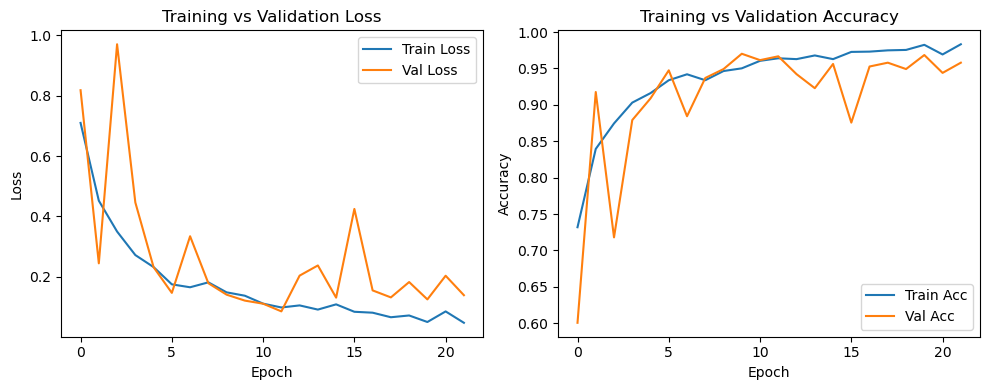

In [17]:
plt.figure(figsize=(10,4))

# --- Loss Plot ---
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# --- Accuracy Plot ---
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Cell 13: Evaluate on Test Set
- The model is evaluated on the test set to determine its final accuracy.
- Confusion matrix is plotted to visualize the model's performance across different classes.

In [18]:
model.eval()  # set to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        preds = preds.argmax(1)  # get class indices
        all_preds.extend(preds.cpu().numpy())   # converts the PyTorch tensor into a NumPy array, which is easier to manipulate in Python
        all_labels.extend(y.cpu().numpy())


In [19]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 95.65%


In [20]:
from sklearn.metrics import confusion_matrix

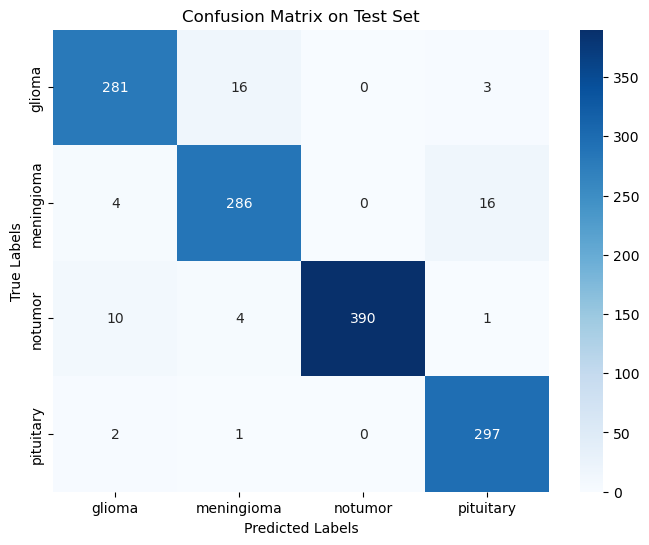

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' ,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix on Test Set')
plt.show()

### Cell 14: Install OpenCV
- Installs the OpenCV package, if not already installed.

In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Cell 15: Verify OpenCV Installation
- Checks the installed version of OpenCV.

In [2]:
import cv2
print(cv2.__version__)

4.10.0


### Cell 16: Generate Masks for Tumor Segmentation
- For each tumor category, creates a binary mask where the tumor is located.
- Saves the generated masks in the specified mask directory.

In [ ]:
import os
import cv2
import numpy as np

train_root = "Training"
mask_root = "Training_masks"

# Get all tumor categories
categories = [cat for cat in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, cat))]

for cat in categories:
    img_dir = os.path.join(train_root, cat)
    mask_dir = os.path.join(mask_root, cat)

    # Create mask folder if not exists
    os.makedirs(mask_dir, exist_ok=True)

    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    print(f"Processing category: {cat}, Total images: {len(img_files)}")

    for img_name in img_files:
        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name)

        # Skip if mask already exists
        if os.path.exists(mask_path):
            continue

        # Read and preprocess
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Normalize & blur
        img = cv2.GaussianBlur(img, (5, 5), 0)

        # Adaptive or Otsu thresholding
        _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological operations to clean small noise
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

        # Optionally invert mask if needed (tumor may appear dark)
        white_ratio = np.sum(mask == 255) / mask.size
        if white_ratio > 0.9:  # too bright => invert
            mask = cv2.bitwise_not(mask)

        # Save mask
        cv2.imwrite(mask_path, mask)

    print(f"✅ Masks generated for category: {cat}")


### Cell 17: Install Additional Packages
- Installs TensorFlow, NumPy, Matplotlib, Scikit-learn, and OpenCV packages.

In [ ]:
!pip install tensorflow numpy matplotlib scikit-learn opencv-python

### Cell 18: Import TensorFlow and Keras Libraries
- `tensorflow`: The main TensorFlow library.
- `layers`, `models`: Keras modules for building and training models.

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Cell 19: Set Image Size
- `IMG_SIZE`: The target size to which all images will be resized.

In [ ]:
train_root = "Training"
mask_root = "Training_masks"

IMG_SIZE = 256  # You can increase to 256 for better accuracy

### Cell 20: Load Dataset Function
- `load_dataset`: A function to load and preprocess images and masks from the specified directories.

In [ ]:
def load_dataset(img_dir, mask_dir, img_size):
    images = []
    masks = []
    categories = [cat for cat in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, cat))]

    for cat in categories:
        img_folder = os.path.join(img_dir, cat)
        mask_folder = os.path.join(mask_dir, cat)

        for filename in os.listdir(img_folder):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(img_folder, filename)
            mask_path = os.path.join(mask_folder, filename)

            if not os.path.exists(mask_path):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (img_size, img_size))
            mask = cv2.resize(mask, (img_size, img_size))

            img = img / 255.0
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

X, y = load_dataset(train_root, mask_root, IMG_SIZE)
print(f"Loaded {len(X)} images and {len(y)} masks")

### Cell 21: Split Data into Training and Validation Sets
- Splits the loaded data into training and validation sets using an 80-20 split.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


### Cell 22: U-Net Model Definition
- Defines the U-Net model architecture for tumor segmentation.

In [ ]:
def unet_model(input_size=(128,128,1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

model = unet_model((IMG_SIZE, IMG_SIZE, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

### Cell 23: Train U-Net Model
- Trains the U-Net model on the tumor segmentation data.

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=20
)

### Cell 24: Visualize Segmentation Results
- Plots a few examples of the original images, ground truth masks, and predicted masks by the U-Net model.

In [ ]:
preds = model.predict(X_val[:5])

plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_val[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 5, i+6)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(3, 5, i+11)
    plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
    plt.title("Predicted")
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Summary of Training and Validation Plots
- The left plot shows **loss** (how wrong the model is) for both training and validation data. Both lines go down, which means the model is learning and making fewer mistakes over time.
- The right plot shows **accuracy** (how often the model is correct). Both lines go up, showing the model is getting better at predicting correctly.
- The training and validation lines are close together, which means the model is not overfitting and works well on new data too.
- In simple words: The model is learning well and making good predictions!

#### What do these plots mean?
- The **loss** plot shows how many mistakes the model makes. If the line goes down, the model is learning and making fewer mistakes.
- The **accuracy** plot shows how often the model gets the answer right. If the line goes up, the model is getting better at its job.
- If both training and validation lines look similar, it means the model is learning well and can work on new data too.
- In short: Lower loss and higher accuracy means the model is improving!

### Simple Summary: How the Model is Trained
1. **Import Libraries:** Load all the tools needed for working with images and building a deep learning model.
2. **Set Up Data:** Point to folders with brain scan images for training and testing.
3. **Prepare Images:** Make sure all images are the same size, have the right number of color channels, and are normalized so the model can learn easily.
4. **Load Data:** Organize images into batches and split them into training and validation sets.
5. **Visualize Data:** Show some sample images to check if everything looks correct.
6. **Build Model:** Use a powerful pre-trained model (EfficientNetV2-S) and adjust it for brain tumor detection.
7. **Set Training Rules:** Choose how the model learns (loss function and optimizer).
8. **Train the Model:** Feed images to the model, let it make predictions, compare those to the correct answers, and adjust itself to improve.
9. **Track Progress:** Plot graphs to see if the model is making fewer mistakes and getting more answers right as it learns.
10. **Test the Model:** Check how well the model works on new, unseen images.
11. **Segment Tumors:** (Extra) Use another model to find and highlight tumors in images.

**In short:** The notebook takes raw brain scan images, prepares them, trains a smart model to recognize tumors, and checks how well it works. The process is step-by-step, just like teaching a student with lots of practice and feedback!